In [1]:
import pandas as pd

# بارگذاری دیتاست شبیه‌سازی‌شده
df = pd.read_csv('simulated_gymnastics_dataset.csv')

In [2]:
print("Shape:", df.shape)
print(df.isnull().sum())
print(df.info())

Shape: (250, 6)
video_id           0
event_label        0
subaction_label    0
start_time         0
end_time           0
talent_label       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         250 non-null    object 
 1   event_label      250 non-null    object 
 2   subaction_label  250 non-null    object 
 3   start_time       250 non-null    float64
 4   end_time         250 non-null    float64
 5   talent_label     250 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 11.8+ KB
None


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['start_time','end_time']] = scaler.fit_transform(df[['start_time','end_time']])

In [4]:
from sklearn.preprocessing import LabelEncoder

le_event = LabelEncoder()
le_sub = LabelEncoder()

df['event_label'] = le_event.fit_transform(df['event_label'])
df['subaction_label'] = le_sub.fit_transform(df['subaction_label'])

In [5]:
from sklearn.model_selection import train_test_split

X = df[['event_label','subaction_label','start_time','end_time']]
y = df['talent_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (200, 4)
Test size: (50, 4)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ساخت مدل
lr_model = LogisticRegression()

# آموزش مدل
lr_model.fit(X_train, y_train)

# پیش‌بینی روی داده تست
y_pred_lr = lr_model.predict(X_test)

# نمایش دقت و گزارش
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# اضافه کردن zero_division=1 برای جلوگیری از هشدار
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, zero_division=1))

Logistic Regression Accuracy: 0.5

Confusion Matrix:
 [[ 0 25]
 [ 0 25]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.00      0.00        25
           1       0.50      1.00      0.67        25

    accuracy                           0.50        50
   macro avg       0.75      0.50      0.33        50
weighted avg       0.75      0.50      0.33        50



In [7]:
from sklearn.ensemble import RandomForestClassifier

# ساخت مدل
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# آموزش مدل
rf_model.fit(X_train, y_train)

# پیش‌بینی روی داده تست
y_pred_rf = rf_model.predict(X_test)

# نمایش دقت و گزارش
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.58

Confusion Matrix:
 [[10 15]
 [ 6 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.40      0.49        25
           1       0.56      0.76      0.64        25

    accuracy                           0.58        50
   macro avg       0.59      0.58      0.57        50
weighted avg       0.59      0.58      0.57        50



In [8]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.5
[[ 0 25]
 [ 0 25]]


In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ساخت مدل بدون use_label_encoder
xgb_model = XGBClassifier(eval_metric='logloss')  # فقط eval_metric کافی است
xgb_model.fit(X_train, y_train)

# پیش‌بینی
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, zero_division=1))  # اضافه کردن zero_division

XGBoost Accuracy: 0.42
[[ 7 18]
 [11 14]]
              precision    recall  f1-score   support

           0       0.39      0.28      0.33        25
           1       0.44      0.56      0.49        25

    accuracy                           0.42        50
   macro avg       0.41      0.42      0.41        50
weighted avg       0.41      0.42      0.41        50



In [10]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(16,8), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(confusion_matrix(y_test, y_pred_mlp))

MLP Accuracy: 0.58
[[ 8 17]
 [ 4 21]]


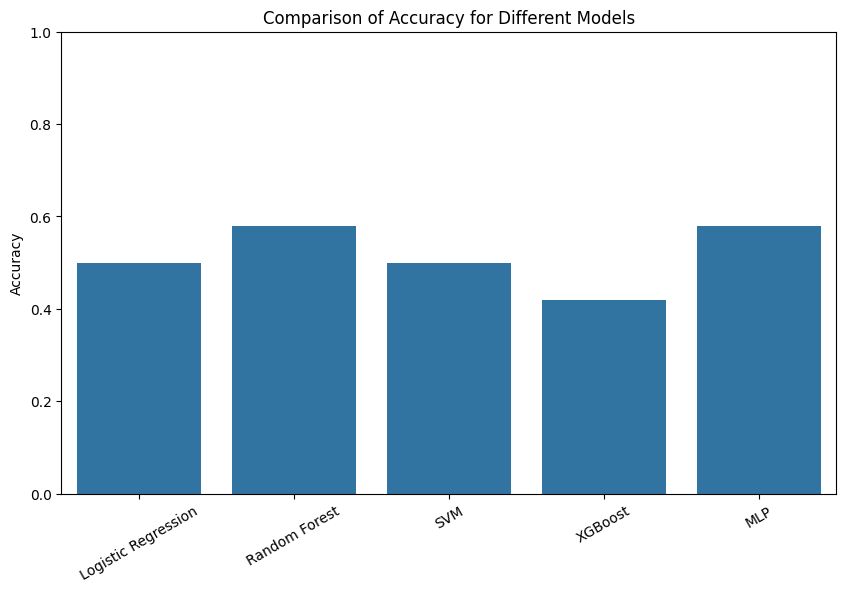

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy مدل‌ها
accuracy_dict = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'MLP': accuracy_score(y_test, y_pred_mlp)
}

# رسم نمودار میله‌ای
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()))
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy for Different Models')
plt.xticks(rotation=30)
plt.show()

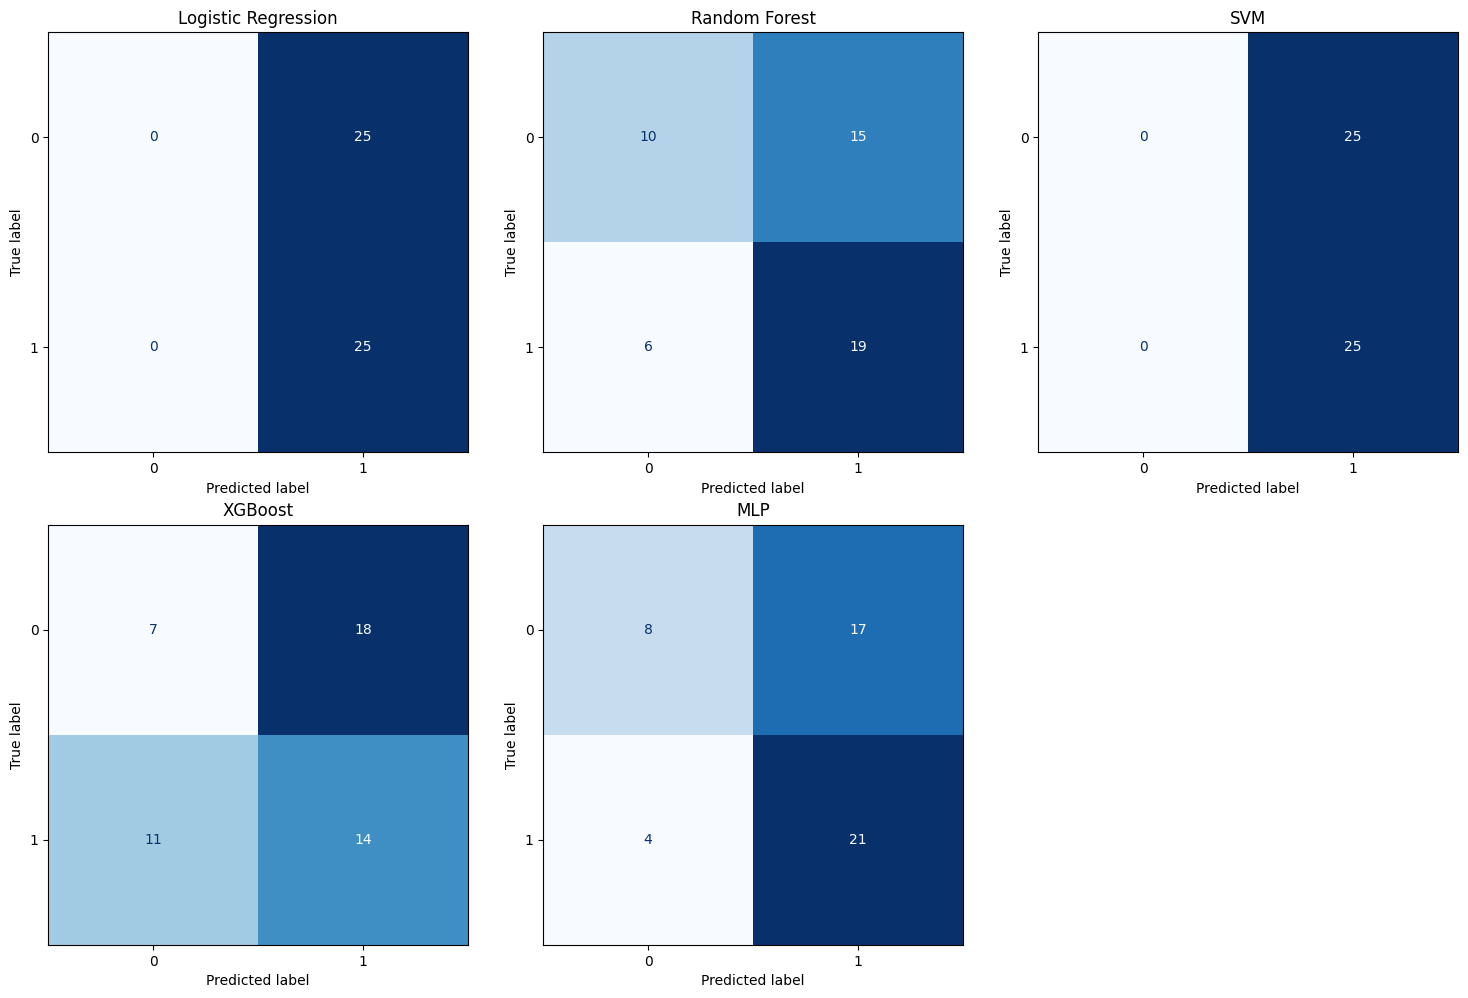

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'XGBoost': y_pred_xgb,
    'MLP': y_pred_mlp
}

plt.figure(figsize=(15,10))

for i, (name, y_pred) in enumerate(models.items(), 1):
    plt.subplot(2,3,i)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
    plt.title(name)

plt.tight_layout()
plt.show()
